In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


deformed_h_list[0]: 1
n: 1 elapsed: 0.038727736473083495
n: 2 elapsed: 0.03972183465957642
n: 3 elapsed: 0.039727318286895755
n: 4 elapsed: 0.0397820512453715
n: 5 elapsed: 0.039825721581776934
n: 6 elapsed: 0.04023528496424357
n: 7 elapsed: 0.04026141961415609
n: 8 elapsed: 0.04029763539632161
n: 9 elapsed: 0.04034053881963094
n: 10 elapsed: 0.04038696686426799
n: 11 elapsed: 0.04049543539683024
n: 12 elapsed: 0.040573803583780925
n: 13 elapsed: 0.040662566820780434
n: 14 elapsed: 0.04073816935221354
n: 15 elapsed: 0.0409052848815918
n: 16 elapsed: 0.04107242027918498
n: 17 elapsed: 0.04122267166773478
n: 18 elapsed: 0.04137783447901408
n: 19 elapsed: 0.04160658518473307
n: 20 elapsed: 0.04184156656265259
n: 21 elapsed: 0.04209167162577311
n: 22 elapsed: 0.04239056905110677
n: 23 elapsed: 0.04272201855977376
n: 24 elapsed: 0.043105137348175046
n: 25 elapsed: 0.04340928395589193
n: 26 elapsed: 0.04380768537521362
n: 27 elapsed: 0.04417210022608439
n: 28 elapsed: 0.044826666514078774
n:

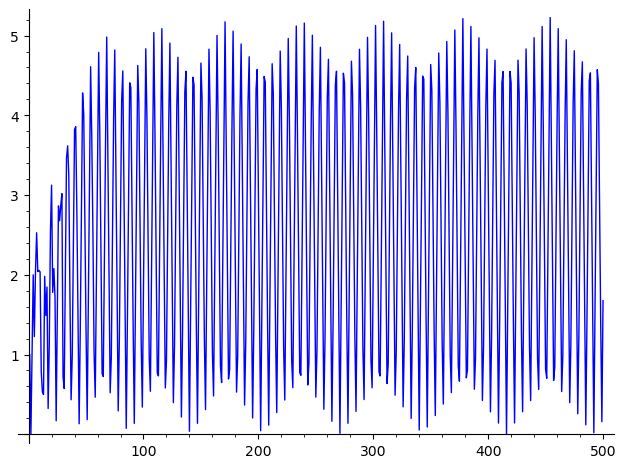

In [2]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(3580) 
h_list=[1]+[nth_prime(k+1)-nth_prime(k)-2 for k in range(1,501)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run16may26no1.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run16may26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run16may26no3.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run16may26no4.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run16may26no5.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)

In [1]:
# these are really chi_lists! No effect on storage.
import pickle
with open('/Users/barrybrent/data2/run16may26no4.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
with open('/Users/barrybrent/data2/run16may26no4a.txt', 'wb') as wfile:
    pickle.dump(mins_list[:100], wfile)
with open('/Users/barrybrent/data2/run16may26no4b.txt', 'wb') as wfile:
    pickle.dump(mins_list[101:200], wfile)
with open('/Users/barrybrent/data2/run16may26no4c.txt', 'wb') as wfile:
    pickle.dump(mins_list[201:300], wfile)
with open('/Users/barrybrent/data2/run16may26no4d.txt', 'wb') as wfile:
    pickle.dump(mins_list[301:400], wfile)
with open('/Users/barrybrent/data2/run16may26no4e.txt', 'wb') as wfile:
    pickle.dump(mins_list[401:500], wfile)

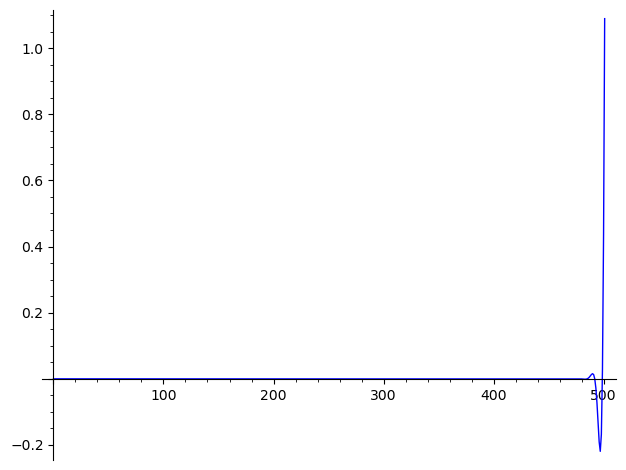

In [1]:
import pickle
with open('/Users/barrybrent/data2/run16may26no2.txt', 'rb') as rfile:
    deformed_h__list = pickle.load(rfile)
p = list_plot(deformed_h__list, plotjoined=True, axes_labels=['', ''])
p.show()

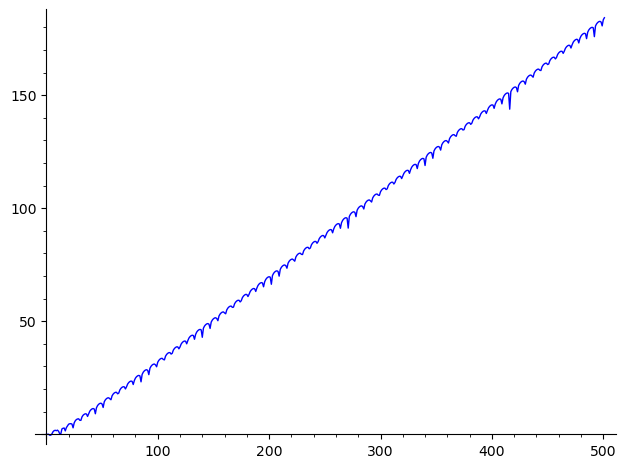

In [11]:
import pickle
with open('/Users/barrybrent/data2/run16may26no2.txt', 'rb') as rfile:
    deformed_h__list = pickle.load(rfile)
logplot=[]
for x in deformed_h__list:
    if x==0:
        logplot.append(0)
    if x>0:
        logplot.append(log(x))
    if x<0:
        logplot.append(log(-x))
        
p = list_plot(logplot, plotjoined=True, axes_labels=['', ''])
p.show()

In [3]:
import pickle
with open('/Users/barrybrent/data2/run16may26no3.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
for pair in mins_list[:3]:
    print(pair)

(1, 1.0000000000000000000000000000)
(2, 0.00000000000000000000000000000)
(3, 1.0000000000000000000000000000)


Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 0.000000 to 5.225736

Stage A: degree-2 polynomial detrend
  lag-1 autocorrelation of residuals: 0.5920
  ACF crosses zero within 166 lags: True
  --> Residual is oscillatory or low-autocorrelation. Polynomial detrend is sufficient.

Final detrending method: Polynomial (degree 2)
  Detrended data std dev: 1.4705

Envelope normalization: not needed
  Envelope dynamic range (p90/p10): 1.09

AR(1) lag-1 autocorrelation (rho): 0.5920
Frequency bins tested: 247
Bonferroni-corrected per-bin alpha: 95% -> 0.000202,  99% -> 0.000040

SIGNIFICANT FFT PEAKS  (period <= N/3 = 167, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            6.85   0.146000     1.34e+05   99%

MULTI-SCALE PERIOD DETECTION
  Period       Scale           ACF strength    Role                
  ----------------------------------------------

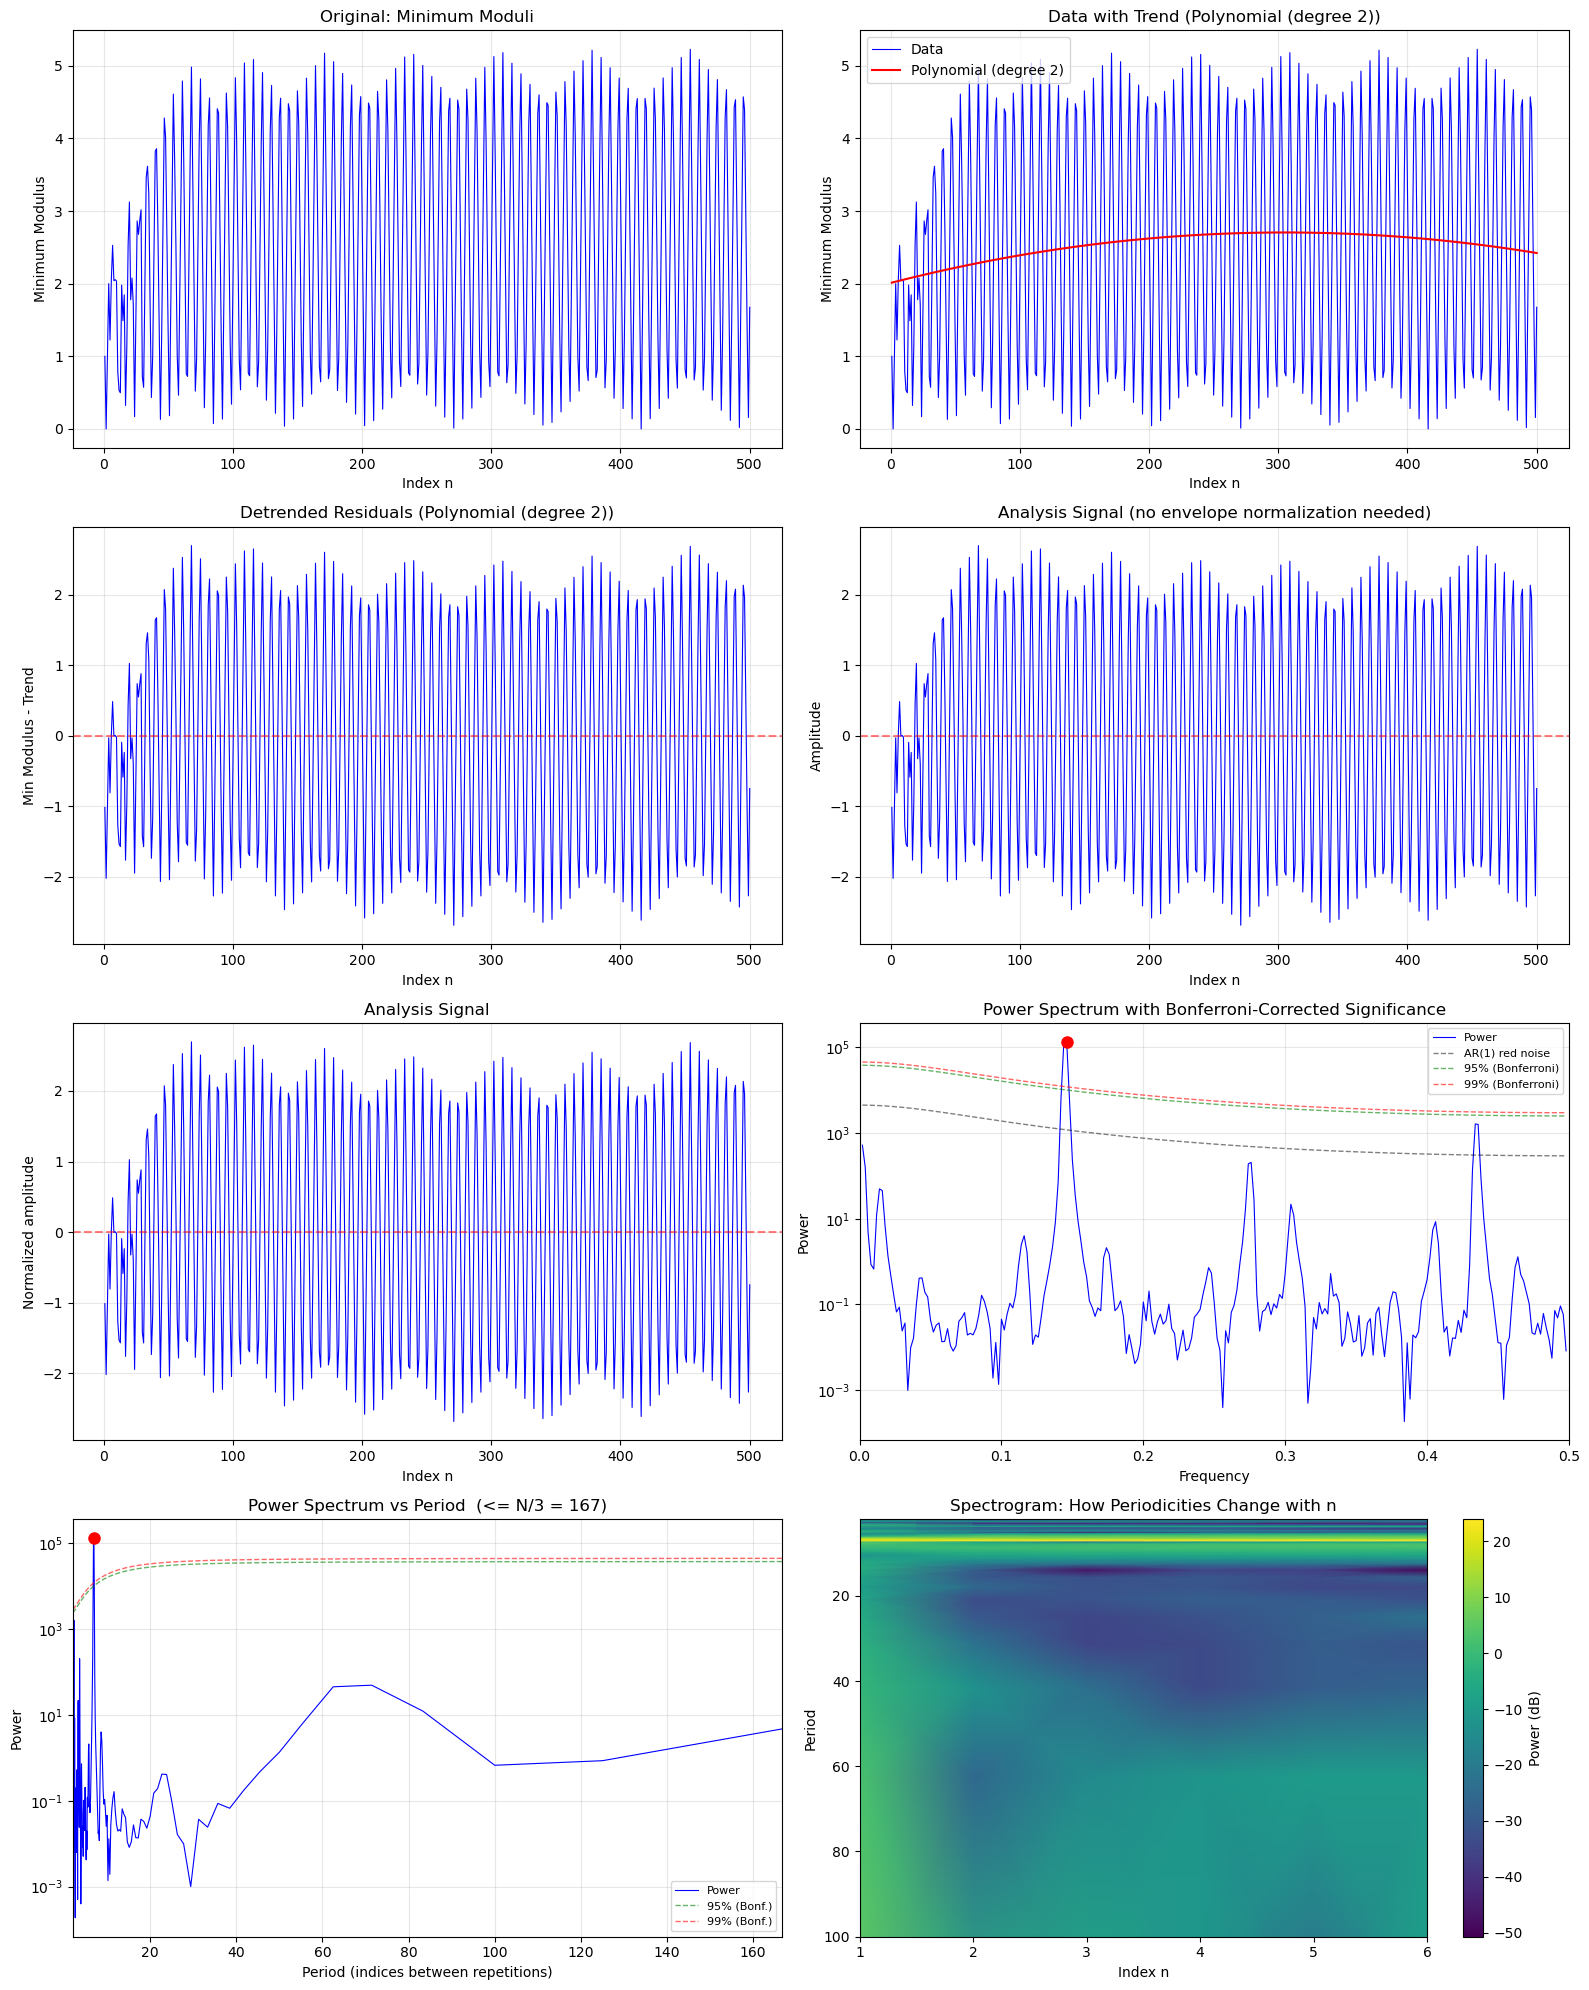


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run16may26no3.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v9.3)
#
# NEW IN v9.3: ENVELOPE NORMALIZATION
#
# v8 had a blind spot for amplitude-modulated periodicity ‚Äî oscillations
# whose envelope decays or grows (e.g., minimum moduli of Chebyshev
# polynomial roots, which oscillate with period 2 but decay as ~1/n).
# Both the ACF and the AR(1) significance test assume roughly stationary
# amplitude.  When amplitude varies strongly:
#   - The ACF is dominated by the high-amplitude portion, producing weak
#     overall correlation.
#   - A negative AR(1) rho models the alternation as noise, raising the
#     significance threshold at high frequencies.
#
# Fix: after detrending, estimate the local amplitude envelope and divide
# it out, producing a signal with approximately constant amplitude.  All
# subsequent analysis (FFT, significance test, multi-scale ACF) operates
# on this normalized signal.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. ADAPTIVE DETRENDING  (safe for both trended and periodic data)
# ==============================================================================
max_credible_period = N / 3.0

# --- Stage A: low-order polynomial (captures broad drift only) ---
poly_deg = 2
poly_coeffs = np.polyfit(indices, minmoduli, deg=poly_deg)
poly_trend = np.polyval(poly_coeffs, indices)
resid_poly = minmoduli - poly_trend

# Measure whether the residual looks "trend-like" or "oscillation-like"
acf_lags = min(50, N // 4)
acf = np.correlate(resid_poly - resid_poly.mean(), resid_poly - resid_poly.mean(), 'full')
acf = acf[N-1:]  # positive lags only
acf = acf / acf[0]  # normalize

check_range = min(int(max_credible_period), len(acf))
acf_crosses_zero = np.any(acf[1:check_range] < 0)
r1_poly = np.corrcoef(resid_poly[:-1], resid_poly[1:])[0, 1]

print(f"\nStage A: degree-{poly_deg} polynomial detrend")
print(f"  lag-1 autocorrelation of residuals: {r1_poly:.4f}")
print(f"  ACF crosses zero within {check_range} lags: {acf_crosses_zero}")

TREND_THRESHOLD = 0.85

if not acf_crosses_zero and abs(r1_poly) > TREND_THRESHOLD:
    # --- Stage B: local smoother needed, but window capped ---
    print(f"  --> Residual is trend-like (r1={r1_poly:.4f}, no zero-crossing).")
    print(f"      Escalating to Savitzky-Golay, window capped at {int(max_credible_period)}.")

    sg_poly_order = 3
    max_sg_win = int(max_credible_period)
    if max_sg_win % 2 == 0:
        max_sg_win -= 1
    max_sg_win = max(max_sg_win, sg_poly_order + 2)

    candidate_windows = [w for w in range(21, max_sg_win + 1, 10) if w % 2 == 1]
    if not candidate_windows:
        candidate_windows = [max_sg_win]

    best_win, best_score = candidate_windows[0], np.inf
    for win in candidate_windows:
        trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
        resid = minmoduli - trend
        r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
        if r1 < best_score:
            best_score = r1
            best_win = win

    smooth_trend = signal.savgol_filter(minmoduli, window_length=best_win,
                                        polyorder=sg_poly_order)
    detrended = minmoduli - smooth_trend
    detrend_label = f"Savitzky-Golay (win={best_win}, order={sg_poly_order})"
    print(f"      Selected window: {best_win}")
    print(f"      lag-1 autocorrelation of residuals: {best_score:.4f}")
else:
    smooth_trend = poly_trend
    detrended = resid_poly
    detrend_label = f"Polynomial (degree {poly_deg})"
    print(f"  --> Residual is oscillatory or low-autocorrelation. "
          f"Polynomial detrend is sufficient.")

print(f"\nFinal detrending method: {detrend_label}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 2b. ENVELOPE NORMALIZATION  (new in v9)
# ==============================================================================
# Estimate the local amplitude envelope of the detrended signal.  If the
# envelope varies by more than a factor of 3 between its 10th and 90th
# percentiles, normalize by it so that the oscillation has roughly constant
# amplitude.  This makes the ACF and significance tests valid for
# amplitude-modulated periodic signals.

abs_detrended = np.abs(detrended)

# Smooth the absolute values to get an envelope estimate.
# Window width: use ~10% of N, at least 5, at most N//3, and must be odd.
env_win = max(5, min(N // 10, N // 3))
if env_win % 2 == 0:
    env_win += 1
envelope = signal.savgol_filter(abs_detrended, window_length=env_win,
                                polyorder=2)

# Floor the envelope to avoid division by near-zero
env_floor = np.percentile(abs_detrended[abs_detrended > 0], 5) if np.any(abs_detrended > 0) else 1.0
envelope = np.maximum(envelope, env_floor)

# Decide whether normalization is needed: check the dynamic range
env_p10 = np.percentile(envelope, 10)
env_p90 = np.percentile(envelope, 90)
envelope_ratio = env_p90 / env_p10 if env_p10 > 0 else 1.0

ENVELOPE_THRESHOLD = 3.0  # normalize if 90th/10th percentile ratio exceeds this

if envelope_ratio > ENVELOPE_THRESHOLD:
    normalized = detrended / envelope
    envelope_applied = True
    print(f"\nEnvelope normalization: APPLIED")
    print(f"  Envelope dynamic range (p90/p10): {envelope_ratio:.2f}")
    print(f"  Envelope smoothing window: {env_win}")
    print(f"  Normalized data std dev: {np.std(normalized):.4f}")
else:
    normalized = detrended
    envelope_applied = False
    print(f"\nEnvelope normalization: not needed")
    print(f"  Envelope dynamic range (p90/p10): {envelope_ratio:.2f}")

# Use the normalized signal for all subsequent analysis
analysis_signal = normalized

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = analysis_signal * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(analysis_signal[:-1], analysis_signal[1:])[0, 1]
variance = np.var(analysis_signal)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS  (FFT)
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

# ==============================================================================
# 5b. MULTI-SCALE FUNDAMENTAL PERIOD DETECTION
# ==============================================================================
# Waveforms can have structure at multiple scales: e.g. a sawtooth with
# period ~60 is built from small teeth with period ~3.  The FFT, naive ACF,
# and time-domain peak-finding all latch onto the finest scale because it
# has the sharpest features.
#
# Strategy: detect periodicity at MULTIPLE SCALES by progressively smoothing
# the analysis signal and re-measuring.  At each scale, compute the ACF
# and find its first peak above a quality threshold.  Collect all detected
# periods across scales and report them hierarchically.
#
# The fundamental is identified as the shortest detected period whose
# integer multiples account for most of the longer detected periods.

detected_periods = []  # list of (period, scale_label, acf_strength)

# Scales to try: raw, then moving-average windows of increasing width
smooth_widths = [1]  # 1 = no smoothing (raw)
w = 3
while w < max_credible_period / 2:
    smooth_widths.append(w)
    w = max(w + 2, int(w * 1.5))
    if w % 2 == 0:
        w += 1

for sw in smooth_widths:
    if sw == 1:
        smoothed = analysis_signal.copy()
        scale_label = "raw"
    else:
        # Moving average
        kernel = np.ones(sw) / sw
        smoothed = np.convolve(analysis_signal, kernel, mode='same')
        scale_label = f"MA({sw})"

    # Compute ACF of smoothed signal
    sm_centered = smoothed - smoothed.mean()
    acf_sm = np.correlate(sm_centered, sm_centered, 'full')
    acf_sm = acf_sm[N-1:]
    if acf_sm[0] > 0:
        acf_sm = acf_sm / acf_sm[0]
    else:
        continue

    # Find first ACF peak above zero with lag >= search_start.
    # Include one extra lag before search_start in the slice so that
    # find_peaks can detect a peak at the boundary (lag = search_start).
    search_start = max(2, sw + 1) if sw > 1 else 2
    search_end = min(int(max_credible_period), len(acf_sm) - 1)
    if search_start >= search_end:
        continue

    slice_begin = max(0, search_start - 1)  # one extra lag for left neighbor
    acf_slice = acf_sm[slice_begin:search_end+1]
    peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)

    # Also check the boundary explicitly: if lag = search_start is a local
    # max relative to its neighbors AND exceeds the height threshold, but
    # find_peaks missed it (e.g. because slice_begin == search_start and
    # it's at index 0), add it manually.
    boundary_offset = search_start - slice_begin
    if (boundary_offset not in peaks_in_slice and
            search_start < len(acf_sm) - 1 and search_start > 0):
        val = acf_sm[search_start]
        left = acf_sm[search_start - 1]
        right = acf_sm[search_start + 1]
        if val > left and val > right and val > 0.1:
            peaks_in_slice = np.concatenate(([boundary_offset], peaks_in_slice))

    if len(peaks_in_slice) > 0:
        # Convert slice indices back to true lags
        true_lags = peaks_in_slice + slice_begin
        # Keep only lags >= search_start
        true_lags = true_lags[true_lags >= search_start]

        if len(true_lags) > 0:
            lag = int(true_lags[0])  # first qualifying peak
            strength = acf_sm[lag]

            # Check this isn't a duplicate of an already-detected period
            is_new = True
            for (prev_p, _, _) in detected_periods:
                if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                    is_new = False
                    break
            if is_new:
                detected_periods.append((float(lag), scale_label, float(strength)))

# Sort by period length (shortest first for fundamental detection)
detected_periods.sort(key=lambda x: x[0])

# Identify the fundamental: the shortest detected period whose integer
# multiples account for most of the longer detected periods.
# (For a period-2 signal, ACF peaks at lags 2, 4, 6, 8, ... are all
# integer multiples of 2.  The fundamental is 2, not 8.)
fund_period = None
fund_method = None
fund_strength = None
sub_periods = []

if detected_periods:
    best_fund_idx = 0
    best_explained = 0

    for i, (cand_p, cand_label, cand_str) in enumerate(detected_periods):
        if cand_p < 2:
            continue
        n_explained = 0
        for j, (other_p, _, _) in enumerate(detected_periods):
            if j == i:
                n_explained += 1
                continue
            ratio = other_p / cand_p
            nearest = round(ratio)
            if nearest >= 1 and abs(ratio - nearest) / max(nearest, 1) < 0.15:
                n_explained += 1
        if n_explained > best_explained or (
                n_explained == best_explained and cand_str > detected_periods[best_fund_idx][2]):
            best_explained = n_explained
            best_fund_idx = i

    fund_period = detected_periods[best_fund_idx][0]
    fund_method = f"multi-scale ACF ({detected_periods[best_fund_idx][1]})"
    fund_strength = detected_periods[best_fund_idx][2]
    sub_periods = [dp for k, dp in enumerate(detected_periods) if k != best_fund_idx]

    # Re-sort sub_periods longest first for display
    sub_periods.sort(key=lambda x: x[0], reverse=True)

# ==============================================================================
# 5c. REPORTING
# ==============================================================================
print("\n" + "="*75)
print(f"SIGNIFICANT FFT PEAKS  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
else:
    print("  No FFT peaks exceed the Bonferroni-corrected significance threshold.")

# --- Multi-scale period detection ---
print("\n" + "="*75)
print("MULTI-SCALE PERIOD DETECTION")
print("="*75)
if fund_period is not None:
    print(f"  {'Period':<12} {'Scale':<15} {'ACF strength':<15} {'Role':<20}")
    print(f"  {'-'*60}")
    print(f"  {fund_period:>8.1f}    {detected_periods[best_fund_idx][1]:<15} "
          f"{fund_strength:>10.4f}      FUNDAMENTAL")
    for (p, label, strength) in sub_periods:
        print(f"  {p:>8.1f}    {label:<15} {strength:>10.4f}      integer multiple")
elif detected_periods:
    print(f"  {'Period':<12} {'Scale':<15} {'ACF strength':<15}")
    print(f"  {'-'*45}")
    for (p, label, strength) in detected_periods:
        print(f"  {p:>8.1f}    {label:<15} {strength:>10.4f}")
else:
    print("  No periodicity detected at any scale.")

# --- Harmonic analysis ---
if fund_period is not None and significant_peaks:
    print(f"\n  Harmonic analysis (FFT peaks as multiples of fundamental "
          f"= {fund_period:.1f}):")
    print(f"  {'Rank':<6} {'FFT Period':<12} {'T_fund / T_peak':<18} "
          f"{'Nearest int':<12} {'Harmonic?':<10}")
    print(f"  {'-'*70}")
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        ratio = fund_period / periods[pi]
        nearest = round(ratio)
        is_harmonic = (nearest >= 1 and
                       abs(ratio - nearest) < 0.15 * max(nearest, 1))
        tag = f"~{nearest}x" if is_harmonic else "independent"
        print(f"  {rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     "
              f"{nearest:>6}     {tag}")

# --- Summary ---
print("\n" + "="*75)
print("SUMMARY")
print("="*75)

# Determine the overall verdict by combining FFT and ACF evidence.
has_fft_evidence = len(significant_peaks) > 0
has_acf_evidence = fund_period is not None and fund_strength > 0.5
has_weak_acf     = fund_period is not None and 0.2 < fund_strength <= 0.5
has_marginal_acf = fund_period is not None and fund_strength <= 0.2

if has_acf_evidence:
    # --- Positive verdict: strong ACF evidence (with or without FFT) ---
    print(f"  PERIODIC.  Fundamental period: {fund_period:.1f}")
    print(f"    Detection method: {fund_method}")
    print(f"    ACF strength: {fund_strength:.4f}")
    if envelope_applied:
        print(f"    Envelope normalization was applied (dynamic range "
              f"{envelope_ratio:.1f}x).")
    if sub_periods:
        sub_str = ", ".join(f"{p:.1f}" for p, _, _ in sub_periods)
        print(f"    Integer multiples also detected at period(s): {sub_str}")
    # Explain FFT vs ACF agreement or disagreement
    if has_fft_evidence:
        print(f"    Evidence: both FFT and ACF confirm periodicity.")
    else:
        if fund_period <= 2.5:
            print(f"    Note: the FFT did not confirm this period.  At period ~2")
            print(f"    (the Nyquist limit), the Hann window strongly attenuates")
            print(f"    the signal.  The ACF is not affected by this limitation.")
        else:
            print(f"    Note: the FFT did not confirm this period (the peak did")
            print(f"    not exceed the Bonferroni-corrected threshold), but the")
            print(f"    ACF strength of {fund_strength:.4f} is strong independent")
            print(f"    evidence of periodicity.")
    # Report FFT harmonic structure if available
    if has_fft_evidence and fund_period is not None:
        dominant_fft_period = periods[significant_peaks[0][0]]
        ratio_to_fund = fund_period / dominant_fft_period
        nearest = round(ratio_to_fund)
        if nearest > 1 and abs(ratio_to_fund - nearest) < 0.15 * nearest:
            print(f"    Dominant FFT peak (period {dominant_fft_period:.2f}) is the "
                  f"~{nearest}x harmonic of the fundamental.")
            print(f"    The waveform is non-sinusoidal.")
        elif nearest <= 1:
            print(f"    Dominant FFT peak (period {dominant_fft_period:.2f}) matches "
                  f"the fundamental.")

elif has_fft_evidence:
    # --- FFT finds peaks but ACF is weak or absent ---
    print(f"  PERIODIC (FFT only).")
    dominant_fft_period = periods[significant_peaks[0][0]]
    print(f"    Dominant FFT period: {dominant_fft_period:.2f}")
    if fund_period is not None:
        print(f"    Multi-scale ACF suggests fundamental: {fund_period:.1f} "
              f"(strength {fund_strength:.4f})")
    print(f"    Note: FFT detects significant peaks, but the multi-scale")
    print(f"    ACF did not find a strong fundamental.  Interpret with caution.")

elif has_weak_acf:
    print(f"  POSSIBLY PERIODIC.  Candidate period: {fund_period:.1f}")
    print(f"    ACF strength {fund_strength:.4f} is moderate (threshold: 0.5).")
    print(f"    The FFT does not confirm.  Interpret with caution.")
    if envelope_applied:
        print(f"    Envelope normalization was applied (dynamic range "
              f"{envelope_ratio:.1f}x).")

elif has_marginal_acf:
    print("  NOT PERIODIC.  Weak ACF signal (strength < 0.2) does not")
    print("  constitute evidence of periodicity.")

else:
    print("  NOT PERIODIC.  Neither the FFT nor the ACF finds evidence")
    print("  of oscillatory behavior.")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=detrend_label)
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Trend ({detrend_label})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data (before envelope normalization)
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals ({detrend_label})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Envelope-normalized data (or detrended if no normalization)
if envelope_applied:
    axes[1, 1].plot(indices, detrended, 'b-', linewidth=0.5, alpha=0.4,
                    label='Detrended')
    axes[1, 1].plot(indices, envelope, 'r-', linewidth=1.5, label='Envelope')
    axes[1, 1].plot(indices, -envelope, 'r-', linewidth=1.5)
    axes[1, 1].set_xlabel('Index n')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].set_title('Detrended Data with Estimated Envelope')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].plot(indices, analysis_signal, 'b-', linewidth=0.8)
    axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Index n')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].set_title('Analysis Signal (no envelope normalization needed)')
    axes[1, 1].grid(True, alpha=0.3)

# 6.5  Normalized signal (what the FFT and ACF actually see)
axes[2, 0].plot(indices, analysis_signal, 'b-', linewidth=0.8)
axes[2, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[2, 0].set_xlabel('Index n')
axes[2, 0].set_ylabel('Normalized amplitude')
title_suffix = " (envelope-normalized)" if envelope_applied else ""
axes[2, 0].set_title(f'Analysis Signal{title_suffix}')
axes[2, 0].grid(True, alpha=0.3)

# 6.6  Power spectrum with corrected confidence bands
axes[2, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[2, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[2, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[2, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[2, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[2, 1].set_xlabel('Frequency')
axes[2, 1].set_ylabel('Power')
axes[2, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[2, 1].legend(fontsize=8)
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_xlim(0, 0.5)

# 6.7  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[3, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[3, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[3, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[3, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[3, 0].set_xlabel('Period (indices between repetitions)')
axes[3, 0].set_ylabel('Power')
axes[3, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[3, 0].legend(fontsize=8)
axes[3, 0].grid(True, alpha=0.3)
axes[3, 0].set_xlim(2, max_credible_period)

# 6.8  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(analysis_signal, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[3, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[3, 1].set_xlabel('Index n')
axes[3, 1].set_ylabel('Period')
axes[3, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[3, 1].set_ylim(2, min(100, max_credible_period))
axes[3, 1].invert_yaxis()
plt.colorbar(im, ax=axes[3, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)


Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 0.000000 to 5.225736

SEGMENTATION  (for context; only the LAST segment is analyzed)
  Breakpoints detected (after merge): 1
  Segment 1: n = 1 to 60  (60 points)  range [0.00, 4.61]
  Segment 2: n = 61 to 500  (440 points)  range [0.00, 5.23]  <-- ANALYZED

FINAL SEGMENT METRICS  (n = 61 to 500, 440 points)

  [Detrending]
    linear-fit slope        : 0.000002
    residual std dev        : 1.505170
    residual / value scale  : 2.880e-01

  [Envelope]
    dynamic range (p90/p10) : 1.029
    monotonicity (|Spearman|): 0.453
    normalization applied   : False

  [Spectral baseline]
    AR(1) lag-1 autocorr rho: 0.5935
    frequency bins tested   : 216
    max credible period     : 146.7  (= n/3)

  [FFT peaks (period <= n/3), strongest first]
      Period        Power Integer(95)% thr Integer(99)% thr  Power/95%
        6.88    1.343e+05    8.720e+03    1.040e+04      15.40
        2.30    1.557e+03    2.243e+03   

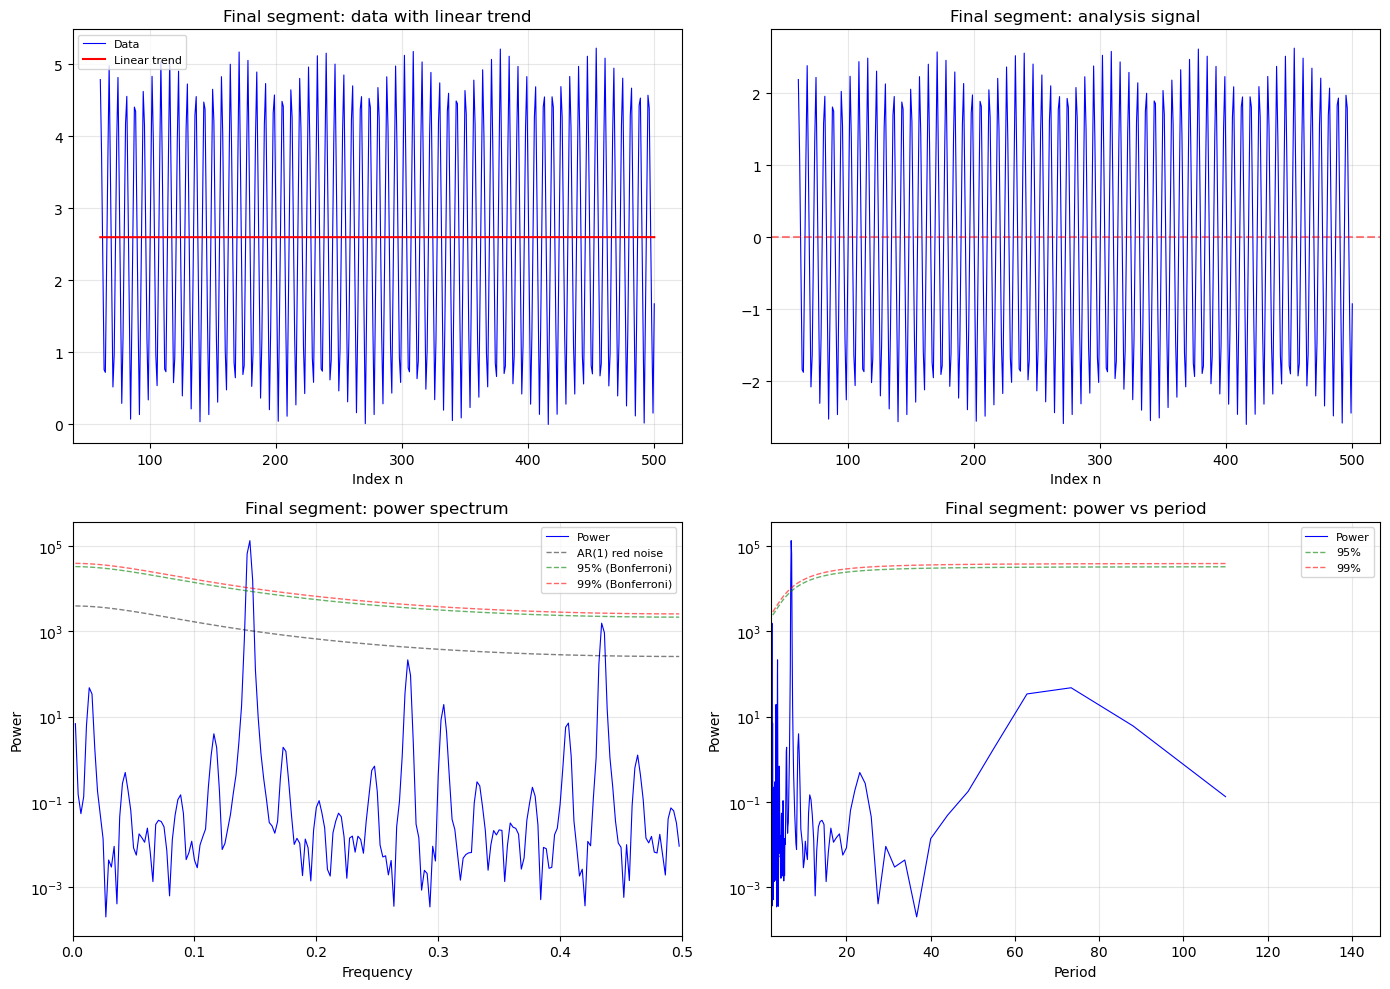


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run16may26no3.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)

# SEGMENTED FOURIER ANALYSIS OF MINIMUM MODULI  (v11)
#
# DESIGN CHANGES RELATIVE TO v10:
#
#  1. LAST SEGMENT ONLY.  The oscillation phenomenon emerges as the index n
#     grows, so only the final segment (after the last structural breakpoint)
#     is analyzed.  Earlier segments are located, reported, and plotted for
#     context only ‚Äî they are not analyzed for periodicity.
#
#  2. NO VERDICTS.  The code does not output PERIODIC / NOT PERIODIC labels.
#     It reports the raw metrics and their scores, and leaves interpretation
#     to the reader.  The metrics are:
#       - linear-detrend slope and residual standard deviation
#       - envelope dynamic range and monotonicity (and whether normalization
#         was applied)
#       - AR(1) lag-1 autocorrelation (rho)
#       - FFT peak periods with their power and the Bonferroni-corrected
#         95% / 99% red-noise thresholds at the same frequency
#       - multi-scale ACF: each detected period, the scale at which it was
#         found, and its ACF strength, with the fundamental identified
#       - the white-noise ACF reference band (1.96 / sqrt(n)), so the ACF
#         strengths can be judged against what white noise would produce
#
#  3. VISUALIZATIONS restricted to the final segment.
#
# Segmentation (level-based ruptures Pelt with l2 cost, plus slope-merge
# cleanup) and the analysis machinery are carried over unchanged from v10.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt
import ruptures as rpt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. BREAKPOINT DETECTION  (level-based, with slope-merge cleanup)
# ==============================================================================
# Used only to locate the final segment.  Detection is the ruptures Pelt
# algorithm with the l2 (mean-shift) cost on the data levels, followed by a
# slope-merge step that collapses adjacent segments of nearly equal slope
# (so an over-segmented linear ramp becomes one segment).

penalty_value = np.log(N) * np.var(minmoduli)
algo = rpt.Pelt(model="l2", min_size=max(20, N // 10)).fit(minmoduli)
breakpoints = algo.predict(pen=penalty_value)
seg_boundaries = [0] + breakpoints

_idx = np.arange(N)
_merged = True
while _merged and len(seg_boundaries) > 2:
    _merged = False
    slopes = []
    for i in range(len(seg_boundaries) - 1):
        s, e = seg_boundaries[i], seg_boundaries[i+1]
        slopes.append(np.polyfit(_idx[s:e], minmoduli[s:e], 1)[0])
    slope_scale = max(abs(max(slopes)), abs(min(slopes)), 1e-9)
    for i in range(len(slopes) - 1):
        if abs(slopes[i] - slopes[i+1]) < 0.15 * slope_scale:
            seg_boundaries.pop(i + 1)
            _merged = True
            break

n_segments = len(seg_boundaries) - 1

print(f"\n{'='*75}")
print(f"SEGMENTATION  (for context; only the LAST segment is analyzed)")
print(f"{'='*75}")
print(f"  Breakpoints detected (after merge): {n_segments - 1}")
for i in range(n_segments):
    start_idx = seg_boundaries[i]
    end_idx = seg_boundaries[i+1]
    si = indices[start_idx:end_idx]
    sv = minmoduli[start_idx:end_idx]
    tag = "  <-- ANALYZED" if i == n_segments - 1 else ""
    print(f"  Segment {i+1}: n = {int(si[0])} to {int(si[-1])}  "
          f"({end_idx - start_idx} points)  "
          f"range [{sv.min():.2f}, {sv.max():.2f}]{tag}")

# ==============================================================================
# 3. METRICS FOR THE FINAL SEGMENT
# ==============================================================================
last_start = seg_boundaries[-2]
last_end = seg_boundaries[-1]
seg_indices = indices[last_start:last_end]
seg_values = minmoduli[last_start:last_end]
n = len(seg_indices)

print(f"\n{'='*75}")
print(f"FINAL SEGMENT METRICS  (n = {int(seg_indices[0])} to {int(seg_indices[-1])}, "
      f"{n} points)")
print(f"{'='*75}")

metrics = {}  # collected for the visualization section

if n < 10:
    print(f"  Final segment too short ({n} points) for analysis.")
    metrics = None
else:
    max_credible_period = n / 3.0

    # --- Linear detrend ---
    coeffs = np.polyfit(seg_indices, seg_values, deg=1)
    trend = np.polyval(coeffs, seg_indices)
    detrended = seg_values - trend
    slope = coeffs[0]

    print(f"\n  [Detrending]")
    print(f"    linear-fit slope        : {slope:.6f}")
    print(f"    residual std dev        : {np.std(detrended):.6f}")

    value_scale = max(np.max(np.abs(seg_values)), 1e-30)
    resid_ratio = np.std(detrended) / value_scale
    print(f"    residual / value scale  : {resid_ratio:.3e}")

    # --- Envelope normalization ---
    abs_det = np.abs(detrended)
    env_win = max(5, min(n // 10, n // 3))
    if env_win % 2 == 0:
        env_win += 1
    env_win = min(env_win, n - 1)
    if env_win % 2 == 0:
        env_win -= 1
    if env_win < 5:
        env_win = 5

    envelope = None
    if env_win >= n:
        envelope_applied = False
        analysis_signal = detrended
        envelope_ratio = float('nan')
        env_monotonicity = float('nan')
    else:
        envelope = signal.savgol_filter(abs_det, window_length=env_win,
                                        polyorder=min(2, env_win - 1))
        env_floor = np.percentile(abs_det[abs_det > 0], 5) if np.any(abs_det > 0) else 1.0
        envelope = np.maximum(envelope, env_floor)
        env_p10 = np.percentile(envelope, 10)
        env_p90 = np.percentile(envelope, 90)
        envelope_ratio = env_p90 / env_p10 if env_p10 > 0 else 1.0
        sp = stats.spearmanr(np.arange(n), envelope).correlation
        env_monotonicity = abs(sp) if sp == sp else 0.0
        if envelope_ratio > 3.0 and env_monotonicity > 0.6:
            analysis_signal = detrended / envelope
            envelope_applied = True
        else:
            analysis_signal = detrended
            envelope_applied = False

    print(f"\n  [Envelope]")
    print(f"    dynamic range (p90/p10) : {envelope_ratio:.3f}")
    print(f"    monotonicity (|Spearman|): {env_monotonicity:.3f}")
    print(f"    normalization applied   : {envelope_applied}")

    # --- Windowed FFT ---
    window = np.hanning(n)
    windowed = analysis_signal * window
    window_power_correction = n / np.sum(window**2)
    fft_result = np.fft.fft(windowed)
    fft_freqs = np.fft.fftfreq(n, d=1.0)
    power_spectrum = np.abs(fft_result)**2 * window_power_correction
    pos = fft_freqs > 0
    frequencies = fft_freqs[pos]
    power = power_spectrum[pos]
    periods = 1.0 / frequencies

    # --- AR(1) red-noise baseline + Bonferroni-corrected thresholds ---
    rho = np.corrcoef(analysis_signal[:-1], analysis_signal[1:])[0, 1]
    variance = np.var(analysis_signal)
    ar1_power = (variance * (1 - rho**2)) / (
        1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
    )
    ar1_power *= np.mean(power) / np.mean(ar1_power)

    credible_mask = periods <= max_credible_period
    n_tests = int(np.sum(credible_mask))
    if n_tests < 1:
        n_tests = 1
    chi2_95 = stats.chi2.ppf(1.0 - (0.05 / n_tests), df=2) / 2.0
    chi2_99 = stats.chi2.ppf(1.0 - (0.01 / n_tests), df=2) / 2.0
    conf_95 = ar1_power * chi2_95
    conf_99 = ar1_power * chi2_99

    print(f"\n  [Spectral baseline]")
    print(f"    AR(1) lag-1 autocorr rho: {rho:.4f}")
    print(f"    frequency bins tested   : {n_tests}")
    print(f"    max credible period     : {max_credible_period:.1f}  (= n/3)")

    # --- FFT peaks: report power against thresholds (no verdict) ---
    peak_idx = signal.find_peaks(power, height=0)[0]
    peak_rows = []
    for pi in peak_idx:
        if not credible_mask[pi]:
            continue
        peak_rows.append((periods[pi], power[pi], conf_95[pi], conf_99[pi],
                          power[pi] / conf_95[pi] if conf_95[pi] > 0 else float('nan')))
    peak_rows.sort(key=lambda r: r[1], reverse=True)

    print(f"\n  [FFT peaks (period <= n/3), strongest first]")
    if peak_rows:
        print(f"    {'Period':>8} {'Power':>12} {'95% thr':>12} {'99% thr':>12} "
              f"{'Power/95%':>10}")
        for per, pw, c95, c99, ratio in peak_rows[:10]:
            print(f"    {per:>8.2f} {pw:>12.3e} {c95:>12.3e} {c99:>12.3e} "
                  f"{ratio:>10.2f}")
    else:
        print(f"    (no FFT peaks with period <= n/3)")

    # --- Multi-scale ACF detection ---
    detected_periods = []
    smooth_widths = [1]
    w = 3
    while w < max_credible_period / 2:
        smooth_widths.append(w)
        w = max(w + 2, int(w * 1.5))
        if w % 2 == 0:
            w += 1

    for sw in smooth_widths:
        if sw == 1:
            smoothed = analysis_signal.copy()
            scale_label = "raw"
        else:
            kernel = np.ones(sw) / sw
            smoothed = np.convolve(analysis_signal, kernel, mode='same')
            scale_label = f"MA({sw})"
        sm_centered = smoothed - smoothed.mean()
        acf_sm = np.correlate(sm_centered, sm_centered, 'full')
        acf_sm = acf_sm[n-1:]
        if acf_sm[0] > 0:
            acf_sm = acf_sm / acf_sm[0]
        else:
            continue
        search_start = max(2, sw + 1) if sw > 1 else 2
        search_end = min(int(max_credible_period), len(acf_sm) - 1)
        if search_start >= search_end:
            continue
        slice_begin = max(0, search_start - 1)
        acf_slice = acf_sm[slice_begin:search_end+1]
        peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)
        boundary_offset = search_start - slice_begin
        if (boundary_offset not in peaks_in_slice and
                search_start < len(acf_sm) - 1 and search_start > 0):
            val = acf_sm[search_start]
            left = acf_sm[search_start - 1]
            right = acf_sm[search_start + 1]
            if val > left and val > right and val > 0.1:
                peaks_in_slice = np.concatenate(([boundary_offset], peaks_in_slice))
        if len(peaks_in_slice) > 0:
            true_lags = peaks_in_slice + slice_begin
            true_lags = true_lags[true_lags >= search_start]
            if len(true_lags) > 0:
                lag = int(true_lags[0])
                strength = acf_sm[lag]
                is_new = True
                for (prev_p, _, _) in detected_periods:
                    if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                        is_new = False
                        break
                if is_new:
                    detected_periods.append((float(lag), scale_label, float(strength)))

    detected_periods.sort(key=lambda x: x[0])

    best_fund_idx = 0
    if detected_periods:
        best_explained = 0
        for i, (cand_p, cand_label, cand_str) in enumerate(detected_periods):
            if cand_p < 2:
                continue
            n_explained = 0
            for j, (other_p, _, _) in enumerate(detected_periods):
                if j == i:
                    n_explained += 1
                    continue
                ratio = other_p / cand_p
                nearest = round(ratio)
                if nearest >= 1 and abs(ratio - nearest) / max(nearest, 1) < 0.15:
                    n_explained += 1
            if n_explained > best_explained or (
                    n_explained == best_explained and
                    cand_str > detected_periods[best_fund_idx][2]):
                best_explained = n_explained
                best_fund_idx = i

    # White-noise reference band for the ACF (Bartlett, large-lag approx)
    acf_wn_band = 1.96 / np.sqrt(n)

    print(f"\n  [Multi-scale ACF]")
    print(f"    white-noise 95% band    : +/- {acf_wn_band:.4f}  (ACF values "
          f"within this band are consistent with noise)")
    if detected_periods:
        print(f"    {'Period':>8} {'Scale':>10} {'ACF strength':>14} "
              f"{'ACF/band':>10}  Role")
        for i, (p, label, strength) in enumerate(detected_periods):
            role = "fundamental" if i == best_fund_idx else "integer multiple"
            print(f"    {p:>8.1f} {label:>10} {strength:>14.4f} "
                  f"{strength/acf_wn_band:>10.2f}  {role}")
    else:
        print(f"    (no ACF peaks above 0.1 at any scale)")

    metrics = {
        'seg_indices': seg_indices, 'seg_values': seg_values,
        'trend': trend, 'detrended': detrended, 'envelope': envelope,
        'analysis_signal': analysis_signal, 'envelope_applied': envelope_applied,
        'frequencies': frequencies, 'power': power, 'periods': periods,
        'ar1_power': ar1_power, 'conf_95': conf_95, 'conf_99': conf_99,
        'peak_rows': peak_rows, 'detected_periods': detected_periods,
        'best_fund_idx': best_fund_idx, 'acf_wn_band': acf_wn_band,
        'max_credible_period': max_credible_period,
    }

# ==============================================================================
# 4. VISUALIZATIONS  (final segment only)
# ==============================================================================
if metrics is not None:
    m = metrics
    si = m['seg_indices']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Data with linear trend (and envelope if applied)
    axes[0, 0].plot(si, m['seg_values'], 'b-', linewidth=0.8, label='Data')
    axes[0, 0].plot(si, m['trend'], 'r-', linewidth=1.5, label='Linear trend')
    axes[0, 0].set_title(f'Final segment: data with linear trend')
    axes[0, 0].set_xlabel('Index n')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

    # Analysis signal (with envelope overlay if applied)
    axes[0, 1].plot(si, m['analysis_signal'], 'b-', linewidth=0.8)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    title = 'Final segment: analysis signal'
    if m['envelope_applied']:
        title += ' (envelope-normalized)'
    axes[0, 1].set_title(title)
    axes[0, 1].set_xlabel('Index n')
    axes[0, 1].grid(True, alpha=0.3)

    # Power spectrum with AR(1) baseline and thresholds
    freq, pwr = m['frequencies'], m['power']
    axes[1, 0].semilogy(freq, pwr, 'b-', linewidth=0.8, label='Power')
    axes[1, 0].semilogy(freq, m['ar1_power'], 'k--', linewidth=1, alpha=0.5,
                        label='AR(1) red noise')
    axes[1, 0].semilogy(freq, m['conf_95'], 'g--', linewidth=1, alpha=0.6,
                        label='95% (Bonferroni)')
    axes[1, 0].semilogy(freq, m['conf_99'], 'r--', linewidth=1, alpha=0.6,
                        label='99% (Bonferroni)')
    axes[1, 0].set_title('Final segment: power spectrum')
    axes[1, 0].set_xlabel('Frequency')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, 0.5)

    # Power vs period
    periods = m['periods']
    max_p = m['max_credible_period']
    pmask = (periods <= max_p) & (periods >= 2)
    if np.any(pmask):
        axes[1, 1].semilogy(periods[pmask], pwr[pmask], 'b-', linewidth=0.8,
                            label='Power')
        axes[1, 1].semilogy(periods[pmask], m['conf_95'][pmask], 'g--',
                            linewidth=1, alpha=0.6, label='95%')
        axes[1, 1].semilogy(periods[pmask], m['conf_99'][pmask], 'r--',
                            linewidth=1, alpha=0.6, label='99%')
        axes[1, 1].set_xlim(2, max_p)
    axes[1, 1].set_title('Final segment: power vs period')
    axes[1, 1].set_xlabel('Period')
    axes[1, 1].set_ylabel('Power')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
